# REINFORCE Small Language Model Credit Assignment

## Objective

In this assignment, you implement the REINFORCE algorithm from scratch and apply it to a small autoregressive character-level language model.

The goal is to understand **temporal credit assignment**: how token decisions made *early* in a sequence receive gradient signal from a reward observed only at the *end* of the sequence.

## Setup

### Vocabulary

We use 5 tokens: `<bos>`, `a`, `b`, `c`, `<eos>`.

The model always starts from `<bos>` (so no token of the actual sequence is forced) and may emit `<eos>` to terminate.

### Reward

The reward is given **only at the end** of the trajectory:

$$R(\tau) = \begin{cases} 1 & \text{if the substring } \texttt{abc} \text{ appears in the sampled sequence} \\ 0 & \text{otherwise} \end{cases}$$

This requires **three correct decisions in a row** (`a` after `<bos>`, then `b`, then `c`), which makes per-timestep credit assignment non-trivial.


In [2]:
# pip install torch matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

torch.manual_seed(0)

vocab = ['<bos>', 'a', 'b', 'c', '<eos>']
stoi = {c: i for i, c in enumerate(vocab)}
itos = {i: c for c, i in stoi.items()}
vocab_size = len(vocab)


## Task 1: Policy network

Implement a memoryless character-level policy $\pi_\theta(a_t \mid a_{t-1})$.

Requirements:
- `nn.Embedding(vocab_size, d)` with `d = 8`
- `nn.Linear(d, vocab_size)` producing logits (do **not** apply softmax inside `forward` — sampling will use `Categorical` directly on logits or on softmaxed probs)

> **Note on memorylessness.** Because each conditioning context (`<bos>`, `a`, `b`, `c`) maps to a *different* desired next token, a memoryless model is sufficient to reach optimal reward.

In [3]:
class CharPolicy(nn.Module):
    def __init__(self, embed_dim: int = 8):
        super().__init__()
        # memoryless policy — just embed the previous token and project to vocab logits
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.head = nn.Linear(embed_dim, vocab_size)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B] token ids -> [B, vocab_size] logits
        # no softmax here, Categorical takes raw logits
        return self.head(self.embed(x))


## Task 2: Sampling

Implement trajectory sampling from the policy.

Specification:
- Start from `<bos>` (this token is **not** included in the returned sequence and contributes **no** log-prob).
- At each step, sample the next token from `Categorical(logits=...)`.
- Stop when `<eos>` is sampled or `max_len` tokens have been produced.
- The log-prob of the sampled `<eos>` (if any) **is** included — the decision to stop is part of the policy.

Return type: `tuple[list[str], torch.Tensor]`
- `seq`: list of token strings actually sampled (may include `<eos>` as the last element)
- `log_probs`: 1-D tensor of shape `[T]` where `T = len(seq)`


In [4]:
def sample(model: CharPolicy, max_len: int = 8) -> tuple[list[str], torch.Tensor]:
    # start from <bos>, but it doesn't go into seq or log_probs
    cur = torch.tensor([stoi['<bos>']])
    seq: list[str] = []
    log_probs: list[torch.Tensor] = []

    for _ in range(max_len):
        logits = model(cur)                                # [1, V]
        dist = torch.distributions.Categorical(logits=logits)
        nxt = dist.sample()                                # [1]
        # keep the log-prob even if we just picked <eos> — stopping is a policy decision
        log_probs.append(dist.log_prob(nxt).squeeze(0))
        tok = itos[nxt.item()]
        seq.append(tok)
        if tok == '<eos>':
            break
        cur = nxt

    return seq, torch.stack(log_probs)


## Task 3: Reward

Implement the terminal reward:

$$R(\tau) = \begin{cases} 1 & \text{if "abc" appears as a substring of } \tau \\ 0 & \text{otherwise} \end{cases}$$

In [5]:
def reward(seq: list[str]) -> float:
    # glue tokens together (drop <eos>) and check for the "abc" substring
    s = ''.join(t for t in seq if t != '<eos>')
    return 1.0 if 'abc' in s else 0.0


## Task 4: REINFORCE update (no baseline)

The policy gradient theorem with terminal-only reward gives:

$$\nabla_\theta J(\theta) = \mathbb{E}_\tau \left[ \sum_{t=1}^{T} G_t \, \nabla_\theta \log \pi_\theta(a_t \mid a_{<t}) \right], \qquad G_t = R(\tau)$$

The corresponding loss for a single sampled trajectory is:

$$\mathcal{L}(\theta) = -R(\tau) \sum_{t=1}^{T} \log \pi_\theta(a_t \mid a_{<t})$$

Implement the training loop:
1. Sample one trajectory.
2. Compute `R`.
3. Compute `loss` per the formula above.
4. `optimizer.zero_grad(); loss.backward(); optimizer.step()`.
5. Track the running average reward and plot it at the end.

Run for **1500** steps. (Cold-start exploration is hard here; without a baseline some seeds may fail to converge — this is exactly the problem Task 4b addresses.)


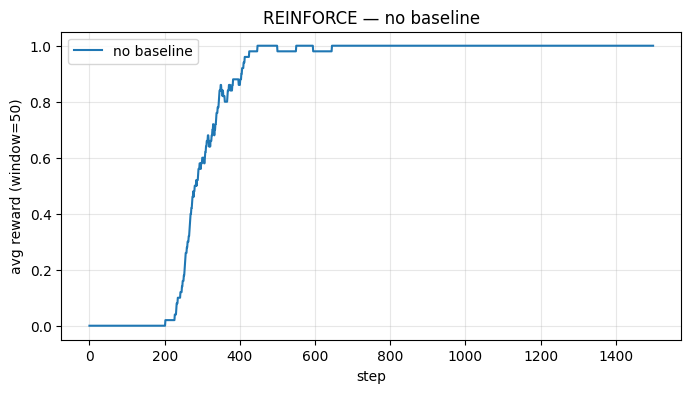

final 100-step avg reward (no baseline): 1.000


In [6]:
torch.manual_seed(0)
model = CharPolicy()
optimizer = optim.Adam(model.parameters(), lr=1e-2)

rewards_no_baseline: list[float] = []

for step in range(1500):
    # 1. roll out one trajectory under the current policy
    seq, log_probs = sample(model)
    # 2. terminal reward — 1 if we hit "abc", else 0
    R = reward(seq)
    # 3. vanilla REINFORCE loss. when R=0 this whole thing is 0 -> zero gradient (the variance problem)
    loss = -R * log_probs.sum()
    # 4. standard SGD step
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    rewards_no_baseline.append(R)

# 5. moving average so we can actually see the trend through the noise
window = 50
ma_no = [sum(rewards_no_baseline[max(0, i - window + 1):i + 1]) / min(i + 1, window)
         for i in range(len(rewards_no_baseline))]

plt.figure(figsize=(8, 4))
plt.plot(ma_no, label='no baseline')
plt.xlabel('step')
plt.ylabel(f'avg reward (window={window})')
plt.title('REINFORCE — no baseline')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f'final 100-step avg reward (no baseline): {sum(rewards_no_baseline[-100:]) / 100:.3f}')


## Task 4b: REINFORCE with a running-mean baseline

The variance of the gradient estimator above is high — half your updates have `R = 0` and produce no gradient. Subtracting a *baseline* `b(s)` that does not depend on the action leaves the gradient unbiased while reducing variance:

$$\mathcal{L}(\theta) = -(R(\tau) - b) \sum_{t} \log \pi_\theta(a_t \mid a_{<t})$$

A simple choice is an exponential moving average of recent returns:

```python
b = 0.9 * b + 0.1 * R
```

Re-train a fresh model with this baseline, log rewards into `rewards_with_baseline`, and plot **both** curves on the same axes. You should see the baselined run reach R≈1 noticeably faster and with less wiggle.


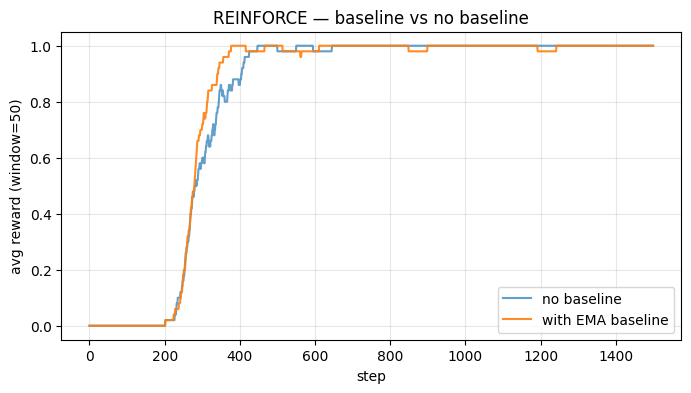

final 100-step avg (no baseline):   1.000
final 100-step avg (with baseline): 1.000


In [7]:
torch.manual_seed(0)
model = CharPolicy()
optimizer = optim.Adam(model.parameters(), lr=1e-2)

rewards_with_baseline: list[float] = []
baseline = 0.0  # EMA of recent returns — starts at 0 since we expect R≈0 early on

for step in range(1500):
    seq, log_probs = sample(model)
    R = reward(seq)
    # advantage can go negative now -> failures actively push the policy AWAY from bad sequences
    advantage = R - baseline
    loss = -advantage * log_probs.sum()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    # update EMA *after* the step, slow enough (alpha=0.1) to act as a stable reference
    baseline = 0.9 * baseline + 0.1 * R
    rewards_with_baseline.append(R)

# plot both runs on the same axes so the variance reduction is obvious
window = 50
ma_no = [sum(rewards_no_baseline[max(0, i - window + 1):i + 1]) / min(i + 1, window)
         for i in range(len(rewards_no_baseline))]
ma_yes = [sum(rewards_with_baseline[max(0, i - window + 1):i + 1]) / min(i + 1, window)
          for i in range(len(rewards_with_baseline))]

plt.figure(figsize=(8, 4))
plt.plot(ma_no, label='no baseline', alpha=0.7)
plt.plot(ma_yes, label='with EMA baseline', alpha=0.9)
plt.xlabel('step')
plt.ylabel(f'avg reward (window={window})')
plt.title('REINFORCE — baseline vs no baseline')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f'final 100-step avg (no baseline):   {sum(rewards_no_baseline[-100:]) / 100:.3f}')
print(f'final 100-step avg (with baseline): {sum(rewards_with_baseline[-100:]) / 100:.3f}')


## Task 5: Credit assignment analysis

Answer the following using the **trained baselined model**.

### 5a. Inspect the learned conditional distributions

Print $\pi_\theta(\cdot \mid x)$ for each $x \in \{\texttt{<bos>}, \texttt{a}, \texttt{b}, \texttt{c}\}$. You should see:

- $\pi(\texttt{a} \mid \texttt{<bos>}) \approx 1$
- $\pi(\texttt{b} \mid \texttt{a}) \approx 1$
- $\pi(\texttt{c} \mid \texttt{b}) \approx 1$
- $\pi(\texttt{<eos>} \mid \texttt{c}) \approx 1$

### 5b. Sample 10 trajectories from the trained model

Print each sampled sequence and its reward.

### 5c. Discussion (3–5 sentences)

Explain, in your own words, why the very first decision $\pi(\cdot \mid \texttt{<bos>})$ ever receives any gradient signal at all, despite the reward being observed only after $\texttt{c}$ is emitted. Reference the term $R(\tau) \cdot \log \pi(a_1 \mid \texttt{<bos>})$ in the loss explicitly.

In [8]:
# 5a — what did the policy actually learn? print pi(. | ctx) for each conditioning token
print('Learned conditional distributions:')
for ctx in ['<bos>', 'a', 'b', 'c']:
    with torch.no_grad():
        logits = model(torch.tensor([stoi[ctx]]))
        probs = torch.softmax(logits, dim=-1).squeeze(0)
    row = ', '.join(f'{tok}={p:.3f}' for tok, p in zip(vocab, probs.tolist()))
    print(f'  pi(. | {ctx:>5s}): {row}')

# 5b — sanity check: 10 rollouts from the trained policy. should mostly be ['a','b','c','<eos>']
print('\n10 sampled trajectories from the trained model:')
for i in range(10):
    seq, _ = sample(model)
    print(f'  [{i:2d}] R={reward(seq):.0f}  {seq}')


Learned conditional distributions:
  pi(. | <bos>): <bos>=0.004, a=0.995, b=0.000, c=0.000, <eos>=0.000
  pi(. |     a): <bos>=0.000, a=0.000, b=0.999, c=0.000, <eos>=0.000
  pi(. |     b): <bos>=0.000, a=0.000, b=0.000, c=0.999, <eos>=0.000
  pi(. |     c): <bos>=0.075, a=0.062, b=0.163, c=0.670, <eos>=0.030

10 sampled trajectories from the trained model:
  [ 0] R=1  ['a', 'b', 'c', '<bos>', 'a', 'b', 'c', 'b']
  [ 1] R=1  ['a', 'b', 'c', 'c', 'a', 'b', 'c', '<bos>']
  [ 2] R=1  ['a', 'b', 'c', 'b', 'c', 'b', 'c', 'c']
  [ 3] R=1  ['a', 'b', 'c', 'b', 'c', 'c', 'c', 'c']
  [ 4] R=1  ['a', 'b', 'c', 'c', 'b', 'c', 'a', 'b']
  [ 5] R=1  ['a', 'b', 'c', 'c', 'b', 'c', 'b', 'c']
  [ 6] R=1  ['a', 'b', 'c', 'b', 'c', 'c', 'c', 'c']
  [ 7] R=1  ['a', 'b', 'c', 'a', 'b', 'c', 'c', 'c']
  [ 8] R=1  ['a', 'b', 'c', 'c', 'c', 'c', 'c', 'c']
  [ 9] R=1  ['a', 'b', 'c', 'b', 'c', 'b', 'c', 'c']


## Expected output (rough)

After 1500 steps with the baseline:
- final 100-step average reward ≥ 0.9
- $\pi(\texttt{a} \mid \texttt{<bos>}) \approx 0.95\text{--}0.99$
- typical sampled trajectory: `['a', 'b', 'c', '<eos>']`

Without the baseline, you may need more steps (or a few re-runs with different seeds) to converge.

### 5c. Why does the first decision ever learn?

The loss includes the term $R(\tau) \cdot \log \pi(a_1 \mid \texttt{<bos>})$, which is an unbiased Monte Carlo estimate of the policy gradient via the log-derivative (score function) trick, so even though the return $G = R(\tau)$ only arrives at the end, it still multiplies the step-1 log-prob and produces a real gradient. 
Whenever a rollout contains "abc", $R = 1$ and that term pushes $\log \pi(a_1 \mid \texttt{<bos>})$ up for whatever token was sampled at $t = 1$, and since `a` is the only first-step choice that *can* lead to a positive return, it's the one whose probability keeps climbing. 
The estimator is unbiased but high-variance because most early rollouts give $R = 0$ and contribute nothing, which is exactly why the EMA baseline helps: the advantage $(R - b)$ keeps the gradient unbiased but lets failures also nudge the policy. 
One thing I noticed is $\pi(\texttt{<eos>} \mid \texttt{c}) \approx 0.03$ instead of $\approx 1$. Once `a→b→c` is emitted, $G$ is already locked at 1, so every action at that step has the same advantage and no gradient differentiates them.

Disclaimer: This assignment was made with the use of LLM to assist and guide through the context